In [1]:
# 1. Tajna transmisja

import torch
from umtools.datasets import load_stream

stream_np = load_stream()
stream = torch.FloatTensor(stream_np)

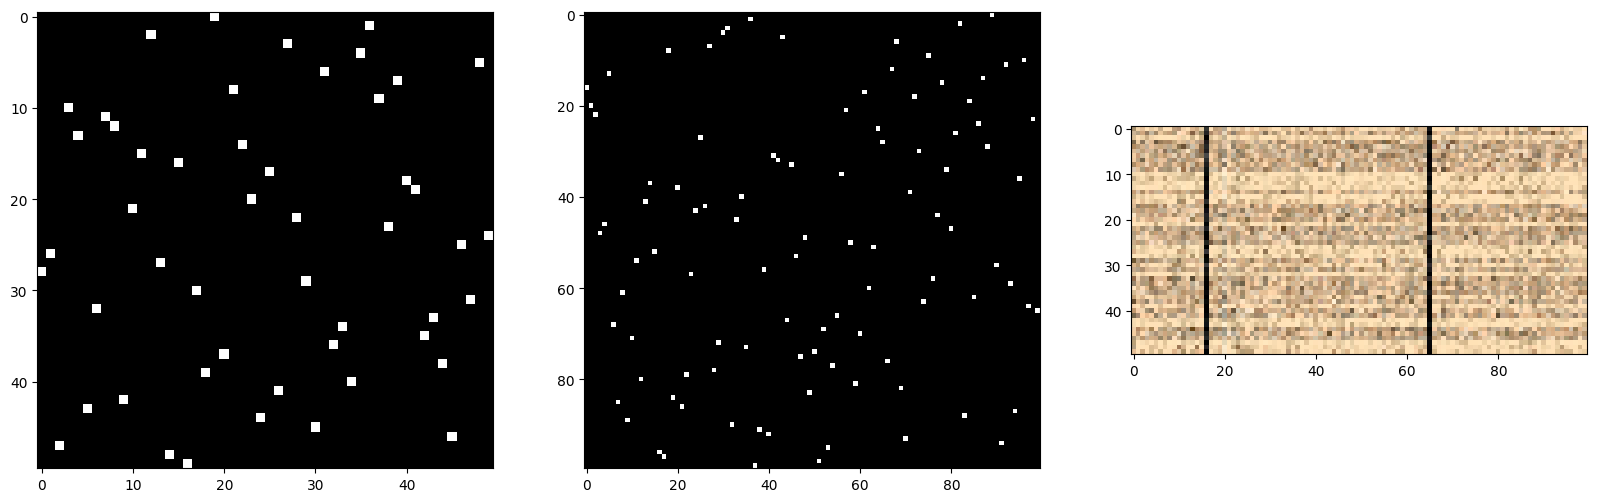

In [2]:
import matplotlib.pyplot as plt
import pickle

size_1 = 50 * 50
img_1 = stream[:size_1].reshape(50, 50)

size_2 = 100 * 100
img_2 = stream[size_1 : size_1 + size_2].reshape(100, 100)

img_3 = stream[size_1 + size_2 :].reshape(50, 100, 5)

with open("reshaped.pkl", "wb") as f:
    pickle.dump(img_3, f)
    
plt.figure(figsize=(20, 10))
plt.subplot(1, 3, 1)
plt.imshow(img_1, cmap="gray")
plt.subplot(1, 3, 2)
plt.imshow(img_2, cmap="gray")
plt.subplot(1, 3, 3)
plt.imshow(img_3[..., :3])


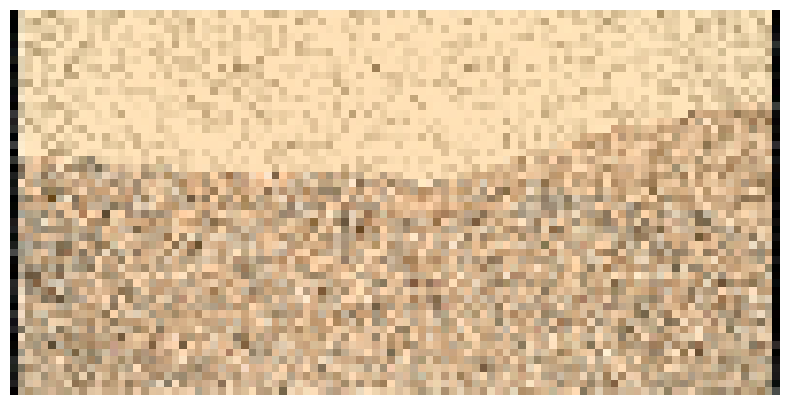

In [3]:
C_rows = img_1
C_cols = img_2
P_enc = img_3

P_enc_CHW = P_enc.permute(2, 0, 1)

pi_rows = C_rows.T.argmax(dim=1)
pi_cols = C_cols.argmax(dim=0)

P_decrypted_CHW = P_enc_CHW[:, pi_rows, :][:, :, pi_cols]

P_decrypted = P_decrypted_CHW.permute(1, 2, 0)

with open("unencrypted.pkl", "wb") as f:
    pickle.dump(P_decrypted, f)

plt.figure(figsize=(10, 5))
plt.imshow(P_decrypted[..., :3])
plt.axis("off")
plt.show()

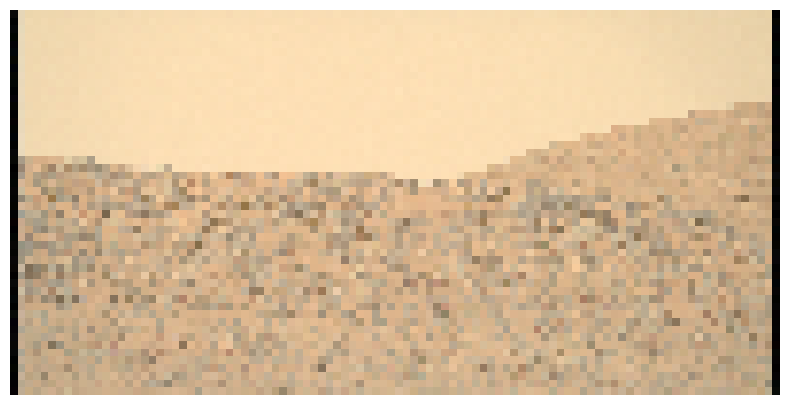

In [4]:
import torch
from umtools.datasets import load_noise

noise = torch.FloatTensor(load_noise())

noise_broadcastable = noise.unsqueeze(-1)
P_denoised = P_decrypted - noise_broadcastable

with open("denoised.pkl", "wb") as f:
    pickle.dump(P_denoised, f)

plt.figure(figsize=(10, 5))
plt.imshow(P_denoised[..., :3]) 
plt.axis("off")
plt.show()

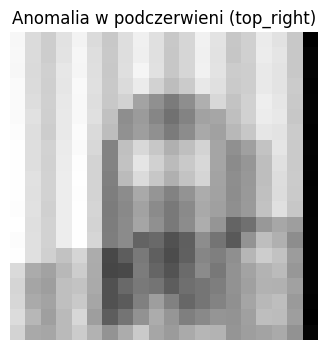

In [5]:
from umtools.utils import save_image

ir_channel = P_denoised[:, :, 3]

corners = {
    "top_left": (slice(None, 20), slice(None, 20)),
    "top_right": (slice(None, 20), slice(-20, None)),
    "bottom_left": (slice(-20, None), slice(None, 20)),
    "bottom_right": (slice(-20, None), slice(-20, None))
}

best_corner = None
max_variance = -1

for name, (y_slice, x_slice) in corners.items():
    corner_ir = ir_channel[y_slice, x_slice]
    variance = corner_ir.var().item()
    
    if variance > max_variance:
        max_variance = variance
        best_corner = name

y_slice, x_slice = corners[best_corner]

alien_crop = P_denoised[y_slice, x_slice, 3] 

save_image(alien_crop, "alien.png")

plt.figure(figsize=(4, 4))
plt.imshow(alien_crop, cmap="gray")
plt.title(f"Anomalia w podczerwieni ({best_corner})")
plt.axis("off")
plt.show()

In [6]:
# 2. Ślepy wędrowiec

from umtools.functions import Hill  

hill = Hill()
lr = 0.05             
num_steps = 500       
max_height_reached = float('-inf')

pos = torch.tensor([1.5, -1.0], requires_grad=True)

for step in range(num_steps):
    h = hill(pos)
    
    current_height = h.item()
    if current_height > max_height_reached:
        max_height_reached = current_height
        
    h.backward()
    
    with torch.no_grad():
        pos += lr * pos.grad
        
    pos.grad.zero_()


with open('max_height.pkl', 'wb') as f:
    pickle.dump([max_height_reached], f)

In [7]:
hill = Hill()
lr = 0.05
num_steps = 200 

pos = torch.empty(2, requires_grad=True)

start_search_data = []

for i in range(10):
    
    with torch.no_grad():
        pos.detach().uniform_(-5.0, 5.0)
        if pos.grad is not None:
            pos.grad.zero_() 
            
    starting_position = pos.tolist()
    starting_height = hill(pos).item()
    max_height = starting_height
    
    for step in range(num_steps):
        h = hill(pos)
        
        current_height = h.item()
        if current_height > max_height:
            max_height = current_height
            
        h.backward()
        
        with torch.no_grad():
            pos += lr * pos.grad
            
        pos.grad.zero_()
        
    start_search_data.append((starting_position, starting_height, max_height))

with open('start_search.pkl', 'wb') as f:
    pickle.dump(start_search_data, f)



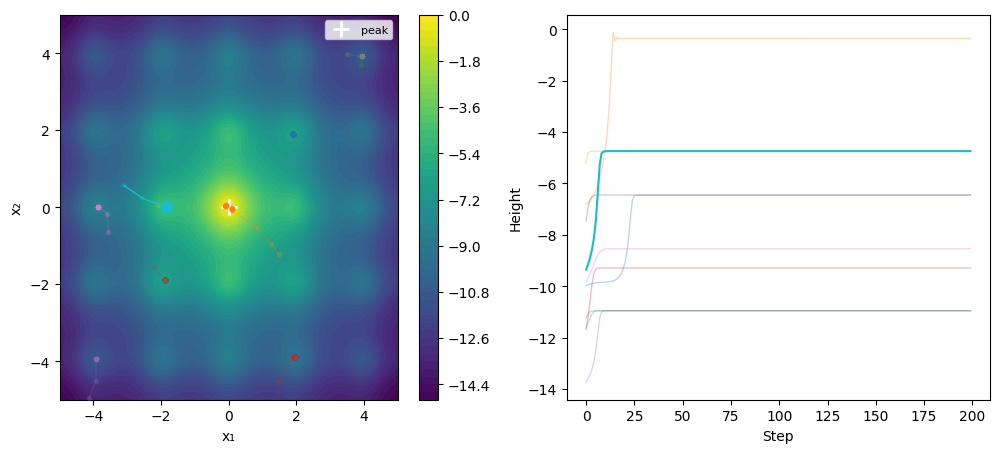

In [8]:
import torch
from umtools.functions import Hill
from umtools.viz import Height, Trace, Visualizer

hill = Hill()
pos = torch.empty(2, requires_grad=True)

t = Trace(hill, pos, kind="contour", update_interval=5) 

h_viz = Height(hill, pos)

viz = Visualizer(update_interval=1).with_trace(t).with_height(h_viz)

for _ in range(10):
    viz.restart() 
    with torch.no_grad():
        pos.detach().uniform_(-5.0, 5.0)
        if pos.grad is not None:
            pos.grad.zero_() 
            
    starting_position = pos.tolist()
    starting_height = hill(pos).item()
    max_height = starting_height
    
    for step in range(num_steps):
        viz.step() 
        
        h_val = hill(pos)
        
        current_height = h_val.item()
        if current_height > max_height:
            max_height = current_height
            
        h_val.backward()
        
        with torch.no_grad():
            pos += lr * pos.grad
            
        pos.grad.zero_()


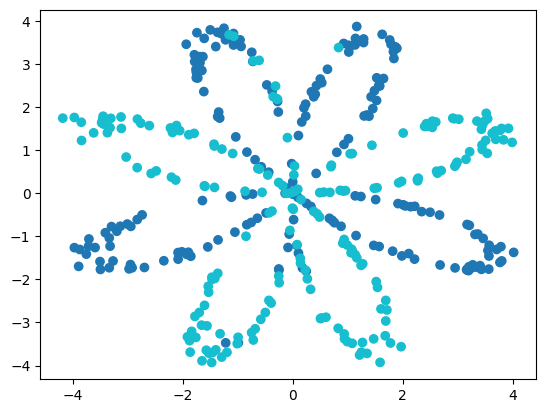

In [9]:
# 3. Wojna kolorów

import matplotlib.pyplot as plt
import torch
from umtools.datasets import make_planar

X, y = make_planar()
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="tab10")

X_t = torch.from_numpy(X).float()
y_t = torch.from_numpy(y).long()


In [10]:
import torch.nn as nn

n_features = 2  
n_classes = 2   

model = nn.Sequential(
    nn.Linear(in_features=n_features, out_features=64),
    nn.ReLU(),
    nn.Linear(in_features=64, out_features=32),
    nn.ReLU(),
    nn.Linear(in_features=32, out_features=n_classes) 
)

In [11]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 500
losses = []

for epoch in range(epochs):
    
    y_pred = model(X_t)
    
    loss = criterion(y_pred, y_t)
    losses.append(loss.item()) 
    
    optimizer.zero_grad()
    
    loss.backward()
    
    optimizer.step()
    
    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}")

plt.figure(figsize=(8, 5))
plt.plot(losses, color='blue')
plt.title('Krzywa uczenia modelu')
plt.xlabel('Epoka')
plt.ylabel('Loss (Strata)')
plt.grid(True)
plt.savefig('torch_loss.png')
plt.close()

with open('torch_loss.pkl', 'wb') as f:
    pickle.dump(losses, f)

Epoch 50/500, Loss: 0.5147
Epoch 100/500, Loss: 0.3762
Epoch 150/500, Loss: 0.3188
Epoch 200/500, Loss: 0.2817
Epoch 250/500, Loss: 0.2531
Epoch 300/500, Loss: 0.2308
Epoch 350/500, Loss: 0.2131
Epoch 400/500, Loss: 0.1990
Epoch 450/500, Loss: 0.1875
Epoch 500/500, Loss: 0.1784


In [12]:
torch.save(model.state_dict(), "color_model.pt")

In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import log_loss

rf_model = RandomForestClassifier(warm_start=True, n_estimators=0, random_state=42)

epochs = 100  
trees_per_epoch = 5
rf_losses = []

for epoch in range(epochs):
    rf_model.n_estimators += trees_per_epoch
    rf_model.fit(X, y)
    y_pred_proba = rf_model.predict_proba(X)
    loss = log_loss(y, y_pred_proba)
    rf_losses.append(loss)

plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), rf_losses, color='green')
plt.title('Krzywa uczenia - Random Forest (Inkrementalne dodawanie drzew)')
plt.xlabel('Iteracja (w każdej dodajemy 5 nowych drzew)')
plt.ylabel('Sklearn Log Loss')
plt.grid(True)
plt.savefig('sklearn_loss.png')
plt.close()


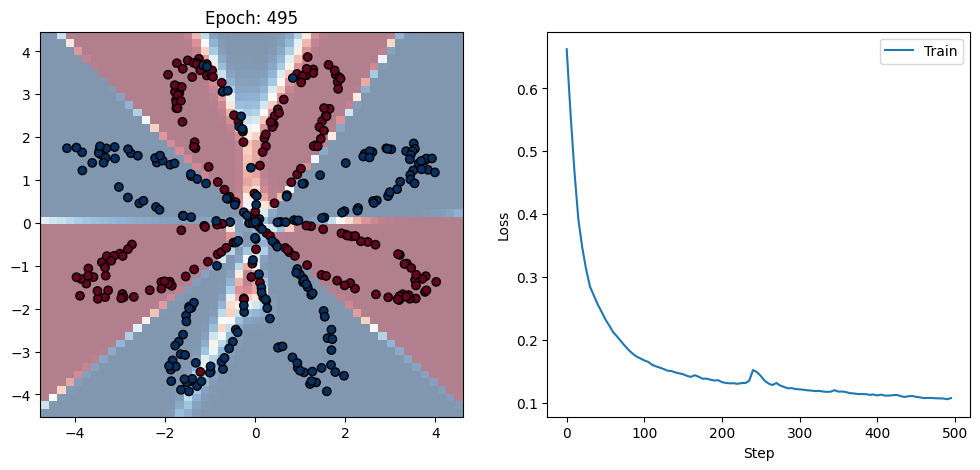

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
from umtools.viz import Boundary, Loss, Visualizer

model = nn.Sequential(
    nn.Linear(in_features=2, out_features=64),
    nn.ReLU(),
    nn.Linear(in_features=64, out_features=32),
    nn.ReLU(),
    nn.Linear(in_features=32, out_features=2) 
)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.01)
b = Boundary(model, X, y, update_interval=5) 
l = Loss(model, criterion, X_t, y_t) 
viz = Visualizer().with_boundary(b).with_loss(l)

epochs = 500

for epoch in range(epochs):
    y_pred = model(X_t)
    loss = criterion(y_pred, y_t)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    viz.step()

In [15]:
# 4. SS Wisła

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
import pickle
from umtools.datasets import load_wisla

train_df, test_df = load_wisla()

In [16]:
def extract_and_clean_features(df):
    df = df.copy()
    
    df['tytul'] = df['pasazer'].apply(lambda x: str(x).split()[0] if pd.notnull(x) else 'Pan')
    df['plec'] = df['tytul'].apply(lambda x: 'kobieta' if x in ['Pani', 'Panna'] else 'mezczyzna')
    
    df['strona_burty'] = df['strona_burty'].fillna('Nieznana')
    df['plec_burta'] = df['plec'] + "_" + df['strona_burty']
    
    valid_features = [
        'wiek', 'rodzenstwo_malzonek', 'rodzice_dzieci', 'oplata', 
        'port_wsiadania', 'strona_burty', 'plec', 'plec_burta'
    ]
    
    if 'przezycie' in df.columns:
        valid_features.append('przezycie')
        
    return df[valid_features]

train_eng = extract_and_clean_features(train_df)
test_eng = extract_and_clean_features(test_df)

In [17]:
Q1 = train_eng['oplata'].quantile(0.25)
Q3 = train_eng['oplata'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

train_filtered = train_eng[(train_eng['oplata'] <= upper_bound) | (train_eng['oplata'].isna())].copy()

In [18]:
X_train_raw = train_filtered.drop(columns=['przezycie'])
y_train_raw = train_filtered['przezycie'].values
X_test_raw = test_eng.copy()

num_features = ['wiek', 'rodzenstwo_malzonek', 'rodzice_dzieci', 'oplata']
cat_features = ['port_wsiadania', 'strona_burty', 'plec', 'plec_burta']

num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_features),
        ('cat', cat_transformer, cat_features)
    ])

X_train_proc = preprocessor.fit_transform(X_train_raw)
X_test_proc = preprocessor.transform(X_test_raw)

In [40]:
X_tr_t = torch.tensor(X_train_proc, dtype=torch.float32)
y_tr_t = torch.tensor(y_train_raw, dtype=torch.float32).unsqueeze(1)

input_dim = X_train_proc.shape[1]

model_wisla = nn.Sequential(
    nn.Linear(input_dim, 8),
    nn.ReLU(),
    nn.Linear(8, 1),
    nn.Sigmoid()
)

criterion = nn.BCELoss()
optimizer = optim.Adam(model_wisla.parameters(), lr=0.003, weight_decay=0.03)

In [41]:
epochs = 80
batch_size = 32

for epoch in range(epochs):
    model_wisla.train()
    permutation = torch.randperm(X_tr_t.size()[0])
    
    for i in range(0, X_tr_t.size()[0], batch_size):
        optimizer.zero_grad()
        indices = permutation[i:i+batch_size]
        batch_x, batch_y = X_tr_t[indices], y_tr_t[indices]

        outputs = model_wisla(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()

In [42]:
model_wisla.eval()
torch.save(model_wisla, 'wisla.pt')

with open('wisla_test.pkl', 'wb') as f:
    pickle.dump(X_test_proc, f)